In [13]:
import pandas
import seaborn
import numpy
import warnings
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.preprocessing import Normalizer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score

In [32]:
aggpops = pandas.read_csv('aggdata/aggpops_transposed(Sheet1).csv')
aggpops.head(15)

,Year,Groningen,Fryslân,Drenthe,Overijssel,Flevoland,Gelderland,Utrecht,Noord-Holland,Zuid-Holland,...,Västra Götaland county,Värmland county,Örebro county,Västmanland county,Dalarna county,Gävleborg county,Västernorrland county,Jämtland county,Västerbotten county,Norrbotten county
0,1942,430271,433541,252367,591063,NaN,951527,497397,1701855,2171832,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1943,432670,436786,261098,598904,NaN,970296,503304,1694657,2162322,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1944,436936,444017,269284,612744,NaN,1003125,513904,1660816,2121548,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1945,441157,452043,264875,620175,NaN,1017876,523605,1671692,2122582,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1946,442462,453109,266524,623616,NaN,1003481,524942,1692390,2161419,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1947,447427,456623,269769,633558,NaN,1019779,544656,1759499,2256454,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1948,453057,460519,273800,644492,NaN,1039025,556391,1794070,2308382,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1949,457611,463442,277258,656047,NaN,1057941,565662,1824305,2351669,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1950,459819,465267,280798,670030,NaN,1077612,573422,1842604,2382898,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1951,461802,467731,285079,682235,NaN,1100976,584176,1874557,2424581,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
aggpops.describe()

,Year,Groningen,Fryslân,Drenthe,Overijssel,Flevoland,Gelderland,Utrecht,Noord-Holland,Zuid-Holland,...,Västra Götaland county,Värmland county,Örebro county,Västmanland county,Dalarna county,Gävleborg county,Västernorrland county,Jämtland county,Västerbotten county,Norrbotten county
count,83.000000,83.000000,83.000000,83.000000,8.300000e+01,39.000000,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,...,5.700000e+01,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000
mean,1983.000000,531735.180723,565271.313253,402387.975904,9.555683e+05,336106.487179,1.638074e+06,9.310933e+05,2.329031e+06,3.075315e+06,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
std,24.103942,49241.332848,73739.736357,81126.006733,1.772726e+05,82553.169552,3.600711e+05,2.621373e+05,3.372866e+05,4.559907e+05,...,1.252935e+05,4435.137134,11507.573041,7718.260066,4967.468065,6444.395902,10495.965288,3249.788570,12563.158815,6823.355824
min,1942.000000,430271.000000,433541.000000,252367.000000,5.910630e+05,177334.000000,9.515270e+05,4.973970e+05,1.660816e+06,2.121548e+06,...,1.333196e+06,272736.000000,269341.000000,248489.000000,275618.000000,275556.000000,241458.000000,126201.000000,232856.000000,248480.000000
25%,1962.500000,483859.000000,485111.500000,322068.000000,8.155645e+05,267584.000000,1.326880e+06,7.031675e+05,2.111209e+06,2.771424e+06,...,1.391774e+06,275003.000000,273608.000000,256889.000000,277349.000000,279991.000000,244105.000000,128586.000000,245055.000000,250497.000000
50%,1983.000000,555200.000000,595248.000000,424720.000000,1.014949e+06,365859.000000,1.727487e+06,9.231820e+05,2.311534e+06,3.129913e+06,...,1.485014e+06,282115.000000,274325.000000,259670.000000,283350.000000,287382.000000,256587.000000,132542.000000,255987.000000,257332.000000
75%,2003.500000,573228.000000,640926.500000,481834.500000,1.103094e+06,400842.000000,1.963676e+06,1.157238e+06,2.580192e+06,3.445962e+06,...,1.580297e+06,284011.000000,280230.000000,261391.000000,286667.000000,292021.000000,266038.000000,134561.000000,259895.000000,264320.000000
max,2024.000000,601347.000000,661904.000000,504129.000000,1.189033e+06,450826.000000,2.149071e+06,1.400057e+06,2.976487e+06,3.840460e+06,...,1.772821e+06,285498.000000,308375.000000,281158.000000,291203.000000,294627.000000,269516.000000,136301.000000,281138.000000,267648.000000


In [15]:
imputedpops = SimpleImputer().set_output(transform='pandas').fit_transform(aggpops)
imputedpops.head(15)

,Year,Groningen,Fryslân,Drenthe,Overijssel,Flevoland,Gelderland,Utrecht,Noord-Holland,Zuid-Holland,...,Västra Götaland county,Värmland county,Örebro county,Västmanland county,Dalarna county,Gävleborg county,Västernorrland county,Jämtland county,Västerbotten county,Norrbotten county
0,1942.0,430271.0,433541.0,252367.0,591063.0,336106.487179,951527.0,497397.0,1701855.0,2171832.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
1,1943.0,432670.0,436786.0,261098.0,598904.0,336106.487179,970296.0,503304.0,1694657.0,2162322.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
2,1944.0,436936.0,444017.0,269284.0,612744.0,336106.487179,1003125.0,513904.0,1660816.0,2121548.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
3,1945.0,441157.0,452043.0,264875.0,620175.0,336106.487179,1017876.0,523605.0,1671692.0,2122582.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
4,1946.0,442462.0,453109.0,266524.0,623616.0,336106.487179,1003481.0,524942.0,1692390.0,2161419.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
5,1947.0,447427.0,456623.0,269769.0,633558.0,336106.487179,1019779.0,544656.0,1759499.0,2256454.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
6,1948.0,453057.0,460519.0,273800.0,644492.0,336106.487179,1039025.0,556391.0,1794070.0,2308382.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
7,1949.0,457611.0,463442.0,277258.0,656047.0,336106.487179,1057941.0,565662.0,1824305.0,2351669.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
8,1950.0,459819.0,465267.0,280798.0,670030.0,336106.487179,1077612.0,573422.0,1842604.0,2382898.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
9,1951.0,461802.0,467731.0,285079.0,682235.0,336106.487179,1100976.0,584176.0,1874557.0,2424581.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702


In [14]:
imputedpops.describe()

,Year,Groningen,Fryslân,Drenthe,Overijssel,Flevoland,Gelderland,Utrecht,Noord-Holland,Zuid-Holland,...,Västra Götaland county,Värmland county,Örebro county,Västmanland county,Dalarna county,Gävleborg county,Västernorrland county,Jämtland county,Västerbotten county,Norrbotten county
count,83.000000,83.000000,83.000000,83.000000,8.300000e+01,83.000000,8.300000e+01,8.300000e+01,8.300000e+01,8.300000e+01,...,8.300000e+01,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,1983.000000,531735.180723,565271.313253,402387.975904,9.555683e+05,336106.487179,1.638074e+06,9.310933e+05,2.329031e+06,3.075315e+06,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
std,24.103942,49241.332848,73739.736357,81126.006733,1.772726e+05,56197.710712,3.600711e+05,2.621373e+05,3.372866e+05,4.559907e+05,...,1.035418e+05,3665.170142,9509.787826,6378.322810,4105.085161,5325.609273,8673.801380,2685.605355,10382.117439,5638.779430
min,1942.000000,430271.000000,433541.000000,252367.000000,5.910630e+05,177334.000000,9.515270e+05,4.973970e+05,1.660816e+06,2.121548e+06,...,1.333196e+06,272736.000000,269341.000000,248489.000000,275618.000000,275556.000000,241458.000000,126201.000000,232856.000000,248480.000000
25%,1962.500000,483859.000000,485111.500000,322068.000000,8.155645e+05,336106.487179,1.326880e+06,7.031675e+05,2.111209e+06,2.771424e+06,...,1.425106e+06,279368.000000,273921.500000,258514.000000,279077.500000,285136.500000,245400.000000,130982.500000,248827.500000,252729.500000
50%,1983.000000,555200.000000,595248.000000,424720.000000,1.014949e+06,336106.487179,1.727487e+06,9.231820e+05,2.311534e+06,3.129913e+06,...,1.504498e+06,280129.122807,278882.000000,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
75%,2003.500000,573228.000000,640926.500000,481834.500000,1.103094e+06,355792.000000,1.963676e+06,1.157238e+06,2.580192e+06,3.445962e+06,...,1.518444e+06,283221.000000,279803.017544,260856.350877,285388.500000,289242.000000,260959.000000,133488.000000,257991.500000,261542.000000
max,2024.000000,601347.000000,661904.000000,504129.000000,1.189033e+06,450826.000000,2.149071e+06,1.400057e+06,2.976487e+06,3.840460e+06,...,1.772821e+06,285498.000000,308375.000000,281158.000000,291203.000000,294627.000000,269516.000000,136301.000000,281138.000000,267648.000000


In [16]:
imputedpops['Year'] = pandas.to_datetime(imputedpops['Year'], format='%Y')
imputedpops.set_index('Year', inplace=True)
imputedpops = imputedpops.asfreq('YS')
imputedpops

,Groningen,Fryslân,Drenthe,Overijssel,Flevoland,Gelderland,Utrecht,Noord-Holland,Zuid-Holland,Zeeland,...,Västra Götaland county,Värmland county,Örebro county,Västmanland county,Dalarna county,Gävleborg county,Västernorrland county,Jämtland county,Västerbotten county,Norrbotten county
Year,,,,,,,,,,,,,,,,,,,,,
1942-01-01,430271.0,433541.0,252367.0,591063.0,336106.487179,951527.0,497397.0,1701855.0,2171832.0,256131.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
1943-01-01,432670.0,436786.0,261098.0,598904.0,336106.487179,970296.0,503304.0,1694657.0,2162322.0,257922.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
1944-01-01,436936.0,444017.0,269284.0,612744.0,336106.487179,1003125.0,513904.0,1660816.0,2121548.0,256459.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
1945-01-01,441157.0,452043.0,264875.0,620175.0,336106.487179,1017876.0,523605.0,1671692.0,2122582.0,227596.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
1946-01-01,442462.0,453109.0,266524.0,623616.0,336106.487179,1003481.0,524942.0,1692390.0,2161419.0,252483.0,...,1.504498e+06,280129.122807,279803.017544,260856.350877,282634.859649,286099.473684,254724.912281,131668.578947,253640.859649,257507.280702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-01,585866.0,649957.0,493682.0,1162406.0,423021.000000,2085952.0,1354834.0,2879527.0,3708696.0,383488.0,...,1.734443e+06,282885.000000,305643.000000,277141.000000,287676.000000,287502.000000,244554.000000,131155.000000,273192.000000,249614.000000
2021-01-01,586937.0,651435.0,494771.0,1166533.0,428226.000000,2096603.0,1361153.0,2888486.0,3726050.0,385400.0,...,1.744859e+06,283196.000000,306792.000000,278967.000000,288387.000000,287767.000000,244193.000000,132054.000000,274563.000000,249693.000000
2022-01-01,590170.0,654019.0,497743.0,1171910.0,434771.000000,2110472.0,1369873.0,2909827.0,3753944.0,386767.0,...,1.758656e+06,283976.000000,307772.000000,280713.000000,288310.000000,287334.000000,243265.000000,132670.000000,276295.000000,249177.000000


In [18]:
warnings.filterwarnings('ignore')

hgsearchfeatures = imputedpops.iloc[:-1]
hgsearchtarget = imputedpops.shift(-1).iloc[:-1]

timesplit = TimeSeriesSplit(n_splits=2)

for fold, (train_idx, test_idx) in enumerate(timesplit.split(hgsearchfeatures), start=1):
    X_train, X_test = hgsearchfeatures.iloc[train_idx].values.reshape(-1,1), hgsearchfeatures.iloc[test_idx].values.reshape(-1,1)
    y_train, y_test = hgsearchtarget.iloc[train_idx].values.reshape(-1,1), hgsearchtarget.iloc[test_idx].values.reshape(-1,1)

In [66]:
mlpparams = {
    'hidden_layer_sizes': [50, 100, 150, 200],
    'activation': ['tanh', 'relu'],
    'solver': ['adam', 'lbfgs'],
    'max_iter': [500, 1000, 1500],
    'early_stopping': [True],
    'momentum': [0.3, 0.5, 0.7, 0.9]
}

testmlp = MLPRegressor()

hgsearch = GridSearchCV(
    estimator=testmlp,
    param_grid=mlpparams,
    cv=timesplit,
    n_jobs=2,
    verbose=1
)

hgsearch.fit(hgsearchfeatures, hgsearchtarget)
hgsearch.best_params_

Fitting 5 folds for each of 192 candidates, totalling 960 fits


{'activation': 'tanh',
 'early_stopping': True,
 'hidden_layer_sizes': 50,
 'max_iter': 1500,
 'momentum': 0.7,
 'solver': 'lbfgs'}

In [68]:
# KNN grid search

knnparams = {
    'n_neighbors': [5, 10, 15, 20, 25],
    'weights': ['uniform', 'distance'],
    'algorithm': ['ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [0, 10, 30, 50, 70]
}

testknn = KNeighborsRegressor()

knnhsearch = GridSearchCV(
    estimator=testknn,
    param_grid=knnparams,
    n_jobs=2,
    cv=timesplit
)

knnhsearch.fit(hgsearchfeatures, hgsearchtarget)
knnhsearch.best_params_

{'algorithm': 'brute',
 'leaf_size': 10,
 'n_neighbors': 5,
 'weights': 'distance'}

In [70]:
# random forest grid search

rfparams = {
    'n_estimators': [100, 200, 300, 400],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
    'bootstrap': [False, True],
    'warm_start': [True, False]
}

testrf = RandomForestRegressor()

rfhsearch = GridSearchCV(
    estimator=testrf,
    param_grid=rfparams,
    n_jobs=2,
    cv=timesplit
)

rfhsearch.fit(hgsearchfeatures, hgsearchtarget)
rfhsearch.best_params_

{'bootstrap': False,
 'criterion': 'absolute_error',
 'n_estimators': 100,
 'warm_start': True}

In [38]:
brf = RandomForestRegressor(
    criterion='absolute_error',
    n_estimators=100,
    bootstrap=False,
    warm_start=True
)

ensemble = StackingRegressor(
    estimators=[
    ('mlp', MLPRegressor(
        max_iter=1500,
        hidden_layer_sizes=50,
        solver='lbfgs',
        learning_rate='adaptive',
        activation='tanh',
        early_stopping=True,
        momentum=0.7
        )
    ),
        
    ('knn', KNeighborsRegressor(
        algorithm='brute',
        leaf_size=10,
        n_neighbors=5,
        weights='distance'
        ))
    ],
    final_estimator=LinearRegression(),
    n_jobs=2,
    passthrough=True
)

algos = [brf, ensemble]

for algo in algos:
    algo.fit(X_train, y_train)

brf_ypred, ens_ypred = (algo.predict(X_test) for algo in algos)

In [39]:
results = {
    'stackingensemble': ens_ypred,
    'randomforest': brf_ypred
}

rmse = {}
mae = {}
mape = {}
r2 = {}

metrics = [rmse, mae, mape, r2]

for algo, preds in results.items():
    rmse[f'{algo}'] = root_mean_squared_error(y_test, preds)
    mae[f'{algo}'] = mean_absolute_error(y_test, preds)
    mape[f'{algo}'] = mean_absolute_percentage_error(y_test, preds)
    r2[f'{algo}'] = r2_score(y_test, preds)

metricsdf = pandas.DataFrame({
    'model': list(rmse.keys()),
    'RMSE': list(rmse.values()),
    'MAE':  list(mae.values()),
    'MAPE': list(mape.values()),
    'R2':   list(r2.values())
})

for algo, preds in results.items():
    print(f'''
    RMSE:
    {algo}: {root_mean_squared_error(y_test, preds)}

    MAE:
    {algo}: {mean_absolute_error(y_test, preds)}    

    MAPE:
    {algo}: {mean_absolute_percentage_error(y_test, preds)}

    R2:
    {algo}: {r2_score(y_test, preds)}
    
    ''')


    RMSE:
    stackingensemble: 61426.628245493426

    MAE:
    stackingensemble: 15059.377446909348    

    MAPE:
    stackingensemble: 0.009133415703991997

    R2:
    stackingensemble: 0.9985335779847484

    

    RMSE:
    randomforest: 143377.08768955123

    MAE:
    randomforest: 40803.61251107845    

    MAPE:
    randomforest: 0.014994352248939882

    R2:
    randomforest: 0.9920107662704424

    


In [30]:
joblib.dump(ensemble, 'stackensemble')
joblib.dump(brf, 'randforest')

['randforest']

<Axes: xlabel='model', ylabel='RMSE'>

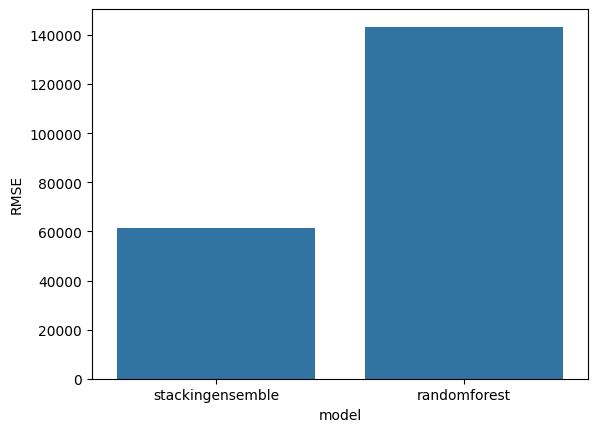

In [40]:
seaborn.barplot(data=metricsdf, x='model', y='RMSE')

<Axes: xlabel='model', ylabel='MAE'>

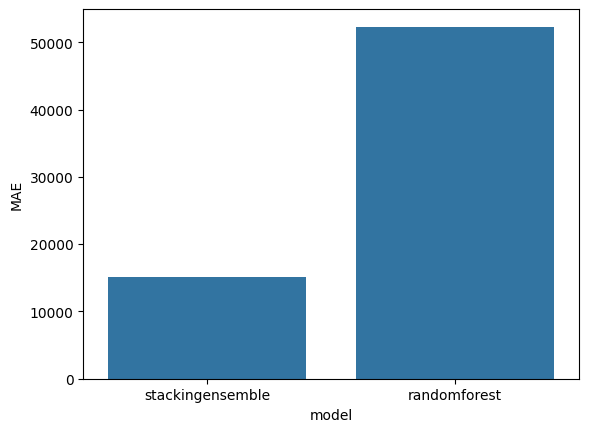

In [34]:
seaborn.barplot(data=metricsdf, x='model', y='MAE')

<Axes: xlabel='model', ylabel='MAPE'>

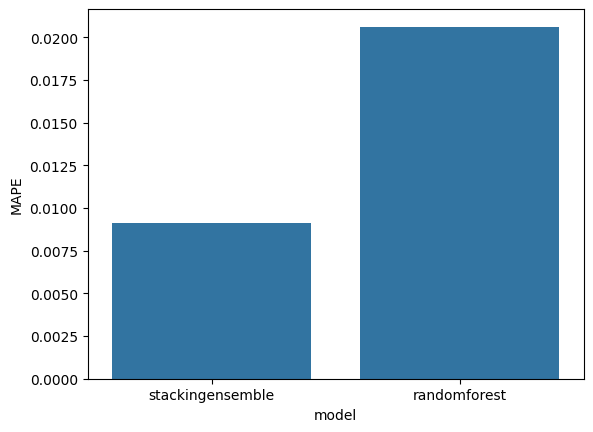

In [35]:
seaborn.barplot(data=metricsdf, x='model', y='MAPE')

<Axes: xlabel='model', ylabel='R2'>

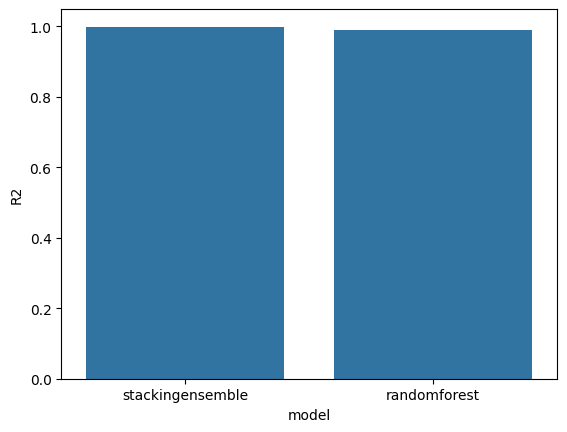

In [36]:
seaborn.barplot(data=metricsdf, x='model', y='R2')